In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Install all necessary libraries
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install pytorch-lightning pycocotools einops pywavelets
!pip install opencv-python scikit-image matplotlib
!pip install wandb  # optional for logging
!pip install ultralytics  # for YOLO object detection




Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118


In [4]:
# Step 1: Install required libraries
!pip install --quiet timm einops pytorch-lightning opencv-python matplotlib seaborn lpips

# For diffusion model components
!pip install --quiet diffusers transformers accelerate

# For YOLOv10 object detection
!pip install --quiet ultralytics

# For image quality metrics like NIQE, BRISQUE
!pip install --quiet piq scikit-image

# If wavelet transform is used (like in TriFuse)
!pip install --quiet PyWavelets

print("✅ All packages installed successfully.")


✅ All packages installed successfully.


In [5]:
# Step 2: Verify dataset folder structure

import os

# Update this path if your dataset folder name is different
BASE_PATH = '/kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset'

for split in ['Train', 'Val', 'Test']:
    split_path = os.path.join(BASE_PATH, split)
    print(f"\n📁 {split} folder contents:")
    if os.path.exists(split_path):
        for item in os.listdir(split_path):
            print("   └──", item)
    else:
        print(f"   ⚠️ {split_path} not found!")



📁 Train folder contents:
   └── low
   └── high

📁 Val folder contents:
   └── low
   └── high

📁 Test folder contents:
   └── Test_262.jpg
   └── Test_422.jpg
   └── Test_636.jpg
   └── Test_828.jpg
   └── Test_98.jpg
   └── Test_385.jpg
   └── Test_108.jpg
   └── Test_767.jpg
   └── Test_635.jpg
   └── Test_694.jpg
   └── Test_157.jpg
   └── Test_240.jpg
   └── Test_324.jpg
   └── Test_683.jpg
   └── Test_125.jpg
   └── Test_739.jpg
   └── Test_649.jpg
   └── Test_601.jpg
   └── Test_271.jpg
   └── Test_122.jpg
   └── Test_100.jpg
   └── Test_273.jpg
   └── Test_65.jpg
   └── Test_922.jpg
   └── Test_383.jpg
   └── Test_605.jpg
   └── Test_994.jpg
   └── Test_950.jpg
   └── Test_446.jpg
   └── Test_335.jpg
   └── Test_258.jpg
   └── Test_750.jpg
   └── Test_345.jpg
   └── Test_776.jpg
   └── Test_312.jpg
   └── Test_799.jpg
   └── Test_218.jpg
   └── Test_450.jpg
   └── Test_687.jpg
   └── Test_507.jpg
   └── Test_592.jpg
   └── Test_923.jpg
   └── Test_589.jpg
   └── Test_320.jpg
 

In [6]:
# Step 3: Collect paired image paths for training and validation
import glob

def get_paired_paths(split='Train'):
    low_dir = os.path.join(BASE_PATH, split, 'low')
    high_dir = os.path.join(BASE_PATH, split, 'high')

    low_images = sorted(glob.glob(os.path.join(low_dir, '*.jpg')))
    high_images = sorted(glob.glob(os.path.join(high_dir, '*.jpg')))

    assert len(low_images) == len(high_images), f"❌ Mismatch: {len(low_images)} low vs {len(high_images)} high images"

    print(f"✅ Found {len(low_images)} {split} pairs")

    return list(zip(low_images, high_images))

# Get paired data for Train and Val
train_pairs = get_paired_paths('Train')
val_pairs = get_paired_paths('Val')

# Show few example pairs
for i in range(3):
    print(f"Train pair {i+1}:\n   Low:  {train_pairs[i][0]}\n   High: {train_pairs[i][1]}")


✅ Found 30000 Train pairs
✅ Found 3000 Val pairs
Train pair 1:
   Low:  /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/low/dense_1.jpg
   High: /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/high/dense_1.jpg
Train pair 2:
   Low:  /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/low/dense_10.jpg
   High: /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/high/dense_10.jpg
Train pair 3:
   Low:  /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/low/dense_100.jpg
   High: /kaggle/input/loli-street-low-light-image-enhancement-of-street/LoLI-Street Dataset/Train/high/dense_100.jpg


In [7]:
# Step 4: Define custom PyTorch dataset
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class LoLIImagePairDataset(Dataset):
    def __init__(self, image_pairs, image_size=256):
        self.image_pairs = image_pairs
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),  # Converts to range [0, 1]
        ])

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        low_path, high_path = self.image_pairs[idx]

        low_img = Image.open(low_path).convert("RGB")
        high_img = Image.open(high_path).convert("RGB")

        return {
            'low': self.transform(low_img),
            'high': self.transform(high_img)
        }

# Example: create dataset instance
train_dataset = LoLIImagePairDataset(train_pairs)
val_dataset = LoLIImagePairDataset(val_pairs)

# Test shape of one sample
sample = train_dataset[0]
print(f"Low shape: {sample['low'].shape}, High shape: {sample['high'].shape}")


Low shape: torch.Size([3, 256, 256]), High shape: torch.Size([3, 256, 256])


In [8]:
# Step 5: Create DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 8  # You can increase to 16 or 32 if memory allows

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test one batch
batch = next(iter(train_loader))
print(f"Train batch - Low: {batch['low'].shape}, High: {batch['high'].shape}")


Train batch - Low: torch.Size([8, 3, 256, 256]), High: torch.Size([8, 3, 256, 256])


In [9]:
# Step 6: Define the TriFuse model (simplified version)
import torch.nn as nn
import torch.nn.functional as F
import einops

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class TriFuseNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder branches (3 input branches in paper: original, enhanced1, enhanced2)
        self.enc1 = ConvBlock(3, 64)  # branch 1
        self.enc2 = ConvBlock(3, 64)  # branch 2
        self.enc3 = ConvBlock(3, 64)  # branch 3

        # Fusion
        self.fusion = ConvBlock(64 * 3, 128)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()  # outputs in [0, 1]
        )

    def forward(self, x1, x2, x3):
        f1 = self.enc1(x1)
        f2 = self.enc2(x2)
        f3 = self.enc3(x3)

        # Fuse
        fused = torch.cat([f1, f2, f3], dim=1)
        fused = self.fusion(fused)

        out = self.decoder(fused)
        return out

# Test forward pass with dummy data
model = TriFuseNet()
dummy = torch.randn(1, 3, 256, 256)  # simulate one image

with torch.no_grad():
    out = model(dummy, dummy, dummy)

print("Output shape:", out.shape)


Output shape: torch.Size([1, 3, 256, 256])


In [10]:
# Step 7: Define image enhancement functions
import cv2
import numpy as np
import torchvision.transforms.functional as TF

def apply_hist_eq(img_tensor):
    img = TF.to_pil_image(img_tensor)
    img_np = np.array(img)

    img_yuv = cv2.cvtColor(img_np, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img_out = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    return TF.to_tensor(img_out)

def apply_clahe(img_tensor, clip_limit=2.0, tile_grid_size=(8,8)):
    img = TF.to_pil_image(img_tensor)
    img_np = np.array(img)

    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    img_out = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    return TF.to_tensor(img_out)

# Test using one training image
sample = train_dataset[0]
x1 = sample['low']
x2 = apply_hist_eq(x1)
x3 = apply_clahe(x1)

# Check shapes
print(x1.shape, x2.shape, x3.shape)


torch.Size([3, 256, 256]) torch.Size([3, 256, 256]) torch.Size([3, 256, 256])


In [11]:
# Step 8: Define loss and optimizer
import torch.optim as optim

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss: L1 Loss
criterion = nn.L1Loss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Test training step
sample = train_dataset[0]
x1 = sample['low'].unsqueeze(0).to(device)
x2 = apply_hist_eq(sample['low']).unsqueeze(0).to(device)
x3 = apply_clahe(sample['low']).unsqueeze(0).to(device)
target = sample['high'].unsqueeze(0).to(device)

# Forward pass
output = model(x1, x2, x3)
loss = criterion(output, target)

# Backward
optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"✅ Training step successful — loss: {loss.item():.4f}")


✅ Training step successful — loss: 0.2243


In [12]:
# Step 9: Train over one epoch with dataloader
from tqdm import tqdm

def enhance_batch(batch):
    x1 = batch['low']
    x2 = torch.stack([apply_hist_eq(img) for img in x1])
    x3 = torch.stack([apply_clahe(img) for img in x1])
    return x1, x2, x3

model.train()

for batch in tqdm(train_loader, desc="Training"):
    x1, x2, x3 = enhance_batch(batch)

    x1 = x1.to(device)
    x2 = x2.to(device)
    x3 = x3.to(device)
    y = batch['high'].to(device)

    out = model(x1, x2, x3)
    loss = criterion(out, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Batch loss: {loss.item():.4f}")
    break  # remove this break to run full epoch


Training:   0%|          | 0/3750 [00:00<?, ?it/s]

Batch loss: 0.2344


In [13]:
# Step 10: Full training + validation loop and checkpoint saving

NUM_EPOCHS = 1  # increase later as needed
SAVE_PATH = "trifuse_epoch1.pth"

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        x1, x2, x3 = enhance_batch(batch)
        x1, x2, x3 = x1.to(device), x2.to(device), x3.to(device)
        y = batch['high'].to(device)

        out = model(x1, x2, x3)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} — Avg Train Loss: {avg_train_loss:.4f}")

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x1, x2, x3 = enhance_batch(batch)
            x1, x2, x3 = x1.to(device), x2.to(device), x3.to(device)
            y = batch['high'].to(device)

            out = model(x1, x2, x3)
            loss = criterion(out, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"📉 Avg Val Loss: {avg_val_loss:.4f}")

    # Save model
    torch.save(model.state_dict(), SAVE_PATH)
    print(f"💾 Model saved to: {SAVE_PATH}")


Epoch 1 - Training: 100%|██████████| 3750/3750 [27:26<00:00,  2.28it/s]

✅ Epoch 1 — Avg Train Loss: 0.0429


📉 Avg Val Loss: 0.0280
💾 Model saved to: trifuse_epoch1.pth


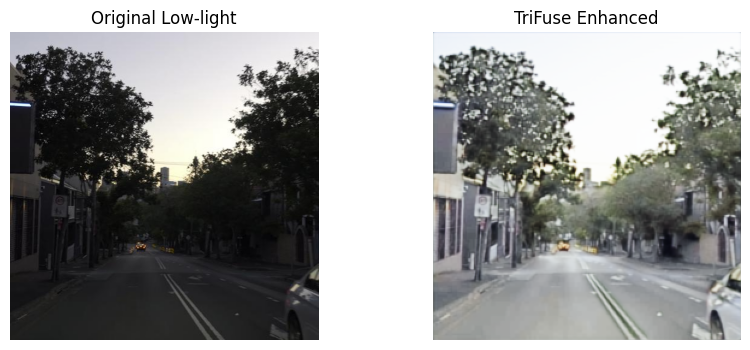

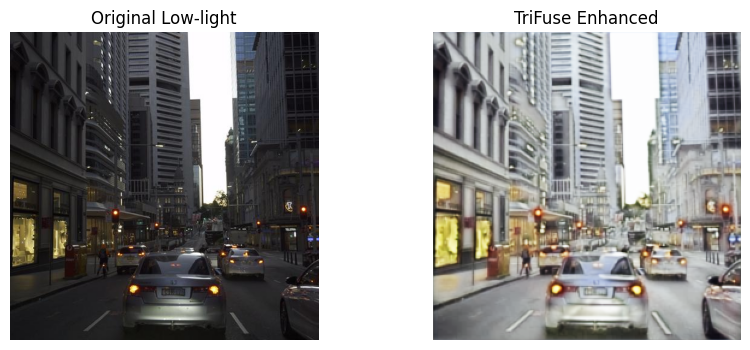

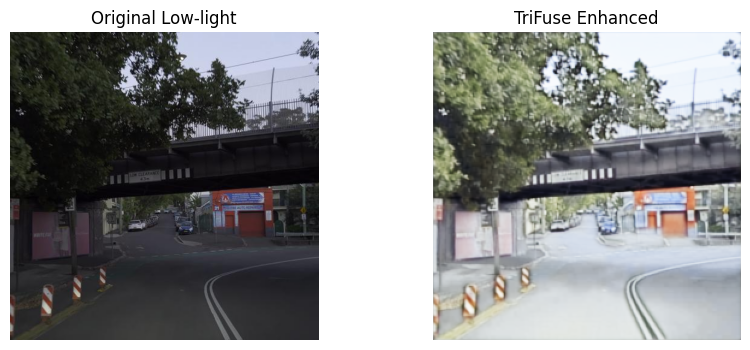

In [14]:
# Step 11: Load trained model & visualize enhanced test images
import matplotlib.pyplot as plt
from PIL import Image

# Load model weights
model.load_state_dict(torch.load("trifuse_epoch1.pth", map_location=device))
model.eval()

# Define path to test images
TEST_PATH = os.path.join(BASE_PATH, 'Test')
test_images = sorted(glob.glob(os.path.join(TEST_PATH, '*.jpg')))

# Pick 3 random test images
test_samples = test_images[:3]

for path in test_samples:
    # Load and preprocess
    img = Image.open(path).convert("RGB")
    img_tensor = transforms.Resize((256, 256))(img)
    img_tensor = TF.to_tensor(img_tensor).unsqueeze(0).to(device)

    # Generate enhanced variants
    x1 = img_tensor
    x2 = apply_hist_eq(img_tensor.squeeze(0)).unsqueeze(0).to(device)
    x3 = apply_clahe(img_tensor.squeeze(0)).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        enhanced = model(x1, x2, x3).squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Show original vs enhanced
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(img)
    axs[0].set_title("Original Low-light")
    axs[0].axis("off")

    axs[1].imshow(enhanced)
    axs[1].set_title("TriFuse Enhanced")
    axs[1].axis("off")
    plt.show()


In [15]:
# Step 12: Run YOLOv10 on TriFuse-enhanced images
from ultralytics import YOLO
import cv2
import numpy as np

# Load pre-trained YOLOv10 model (small version for fast test)
yolo_model = YOLO('yolov10s.pt')  # you can switch to 'yolov10m.pt' if needed

# Make folder to save detection results
os.makedirs("enhanced_yolo_output", exist_ok=True)

for i, path in enumerate(test_samples):
    # Load and enhance test image
    img = Image.open(path).convert("RGB")
    img_tensor = transforms.Resize((256, 256))(img)
    img_tensor = TF.to_tensor(img_tensor).unsqueeze(0).to(device)

    x1 = img_tensor
    x2 = apply_hist_eq(img_tensor.squeeze(0)).unsqueeze(0).to(device)
    x3 = apply_clahe(img_tensor.squeeze(0)).unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced = model(x1, x2, x3).squeeze(0).cpu()

    # Convert tensor to OpenCV format (BGR)
    enhanced_img = enhanced.permute(1, 2, 0).numpy()
    enhanced_img = (enhanced_img * 255).astype(np.uint8)
    enhanced_bgr = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR)

    # Save temporarily to disk (YOLO needs file path)
    temp_path = f"enhanced_yolo_output/test_enhanced_{i}.jpg"
    cv2.imwrite(temp_path, enhanced_bgr)

    # Run YOLOv10 inference
    results = yolo_model(temp_path)

    # Plot and save detection result
    results[0].save(filename=f"enhanced_yolo_output/yolo_detected_{i}.jpg")
    print(f"✅ Saved detection: enhanced_yolo_output/yolo_detected_{i}.jpg")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 15.9M/15.9M [00:00<00:00, 141MB/s]



image 1/1 /kaggle/working/enhanced_yolo_output/test_enhanced_0.jpg: 640x640 2 cars, 14.9ms
Speed: 7.6ms preprocess, 14.9ms inference, 30.0ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved detection: enhanced_yolo_output/yolo_detected_0.jpg

image 1/1 /kaggle/working/enhanced_yolo_output/test_enhanced_1.jpg: 640x640 2 persons, 4 cars, 1 traffic light, 14.9ms
Speed: 2.8ms preprocess, 14.9ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved detection: enhanced_yolo_output/yolo_detected_1.jpg

image 1/1 /kaggle/working/enhanced_yolo_output/test_enhanced_2.jpg: 640x640 2 cars, 14.9ms
Speed: 2.8ms preprocess, 14.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved detection: enhanced_yolo_output/yolo_detected_2.jpg


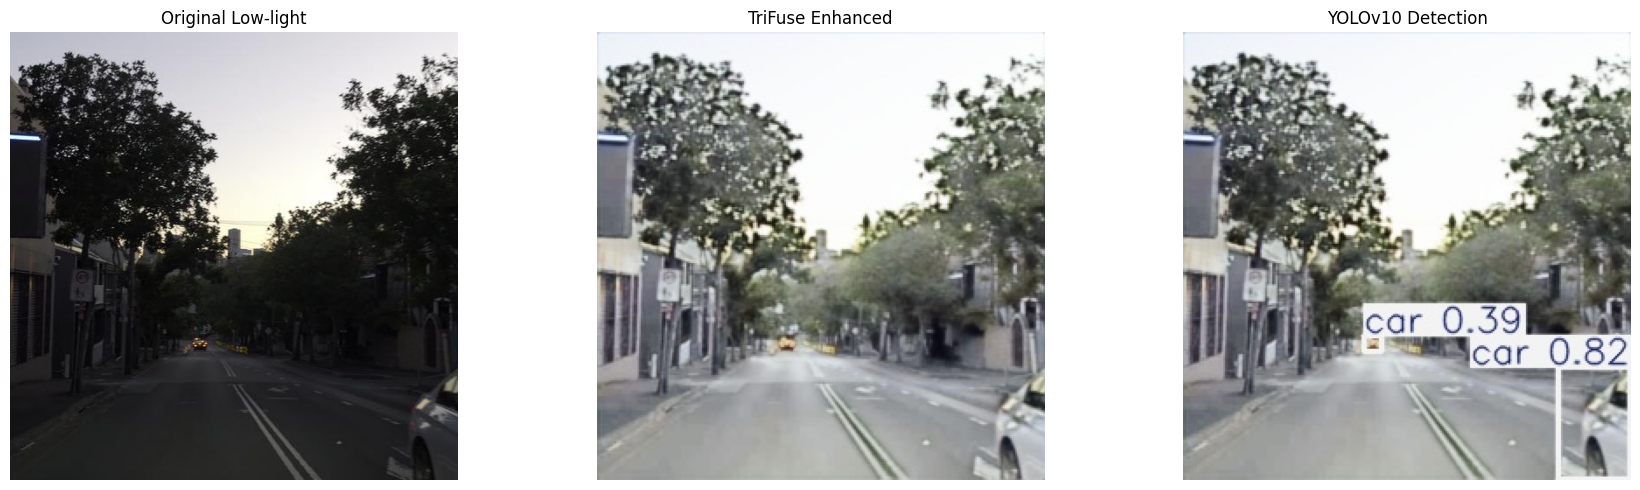

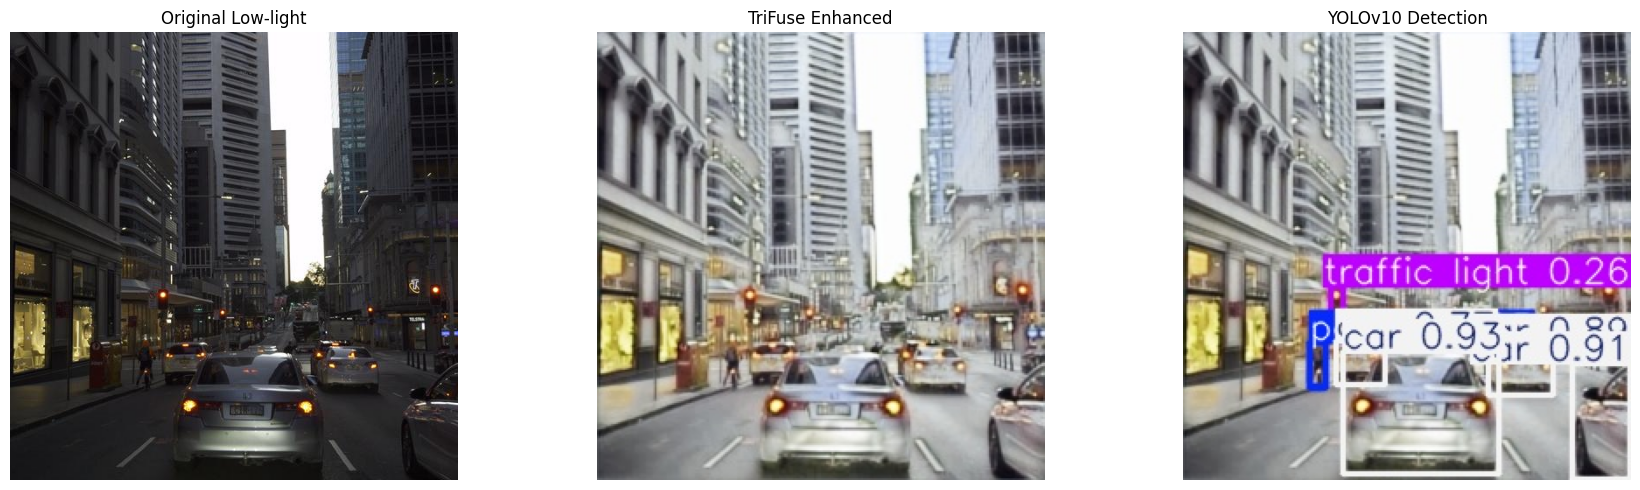

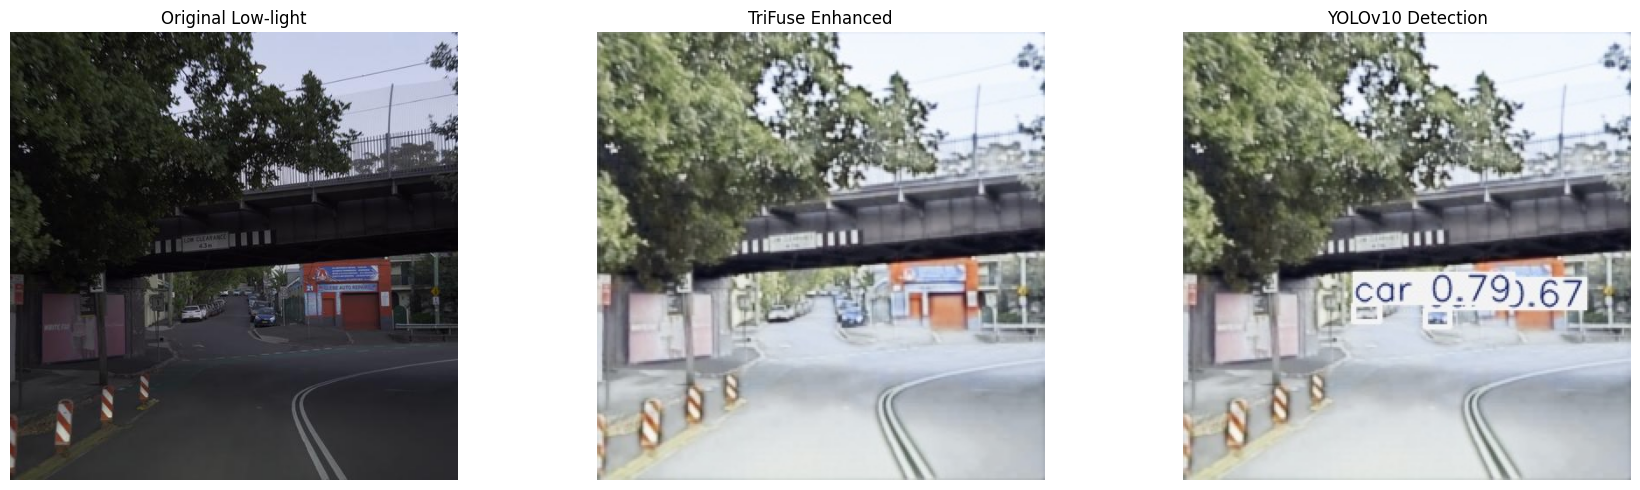

In [16]:
# Step 13: Visualize original, enhanced, and YOLO detection results
import matplotlib.pyplot as plt

for i, path in enumerate(test_samples):
    # Load original
    original = Image.open(path).convert("RGB")

    # Load enhanced image
    enhanced = cv2.imread(f"enhanced_yolo_output/test_enhanced_{i}.jpg")
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    # Load YOLO detection result
    detected = cv2.imread(f"enhanced_yolo_output/yolo_detected_{i}.jpg")
    detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

    # Plot all 3 images
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].imshow(original)
    axs[0].set_title("Original Low-light")
    axs[0].axis("off")

    axs[1].imshow(enhanced_rgb)
    axs[1].set_title("TriFuse Enhanced")
    axs[1].axis("off")

    axs[2].imshow(detected_rgb)
    axs[2].set_title("YOLOv10 Detection")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()
